# **Data Science Assignment 3**

Abdul Hadi 22F-3582 & Ahmad Tayyab 22F-8817

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import math
import itertools
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(url)
print("Shape:", df.shape)
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## **Part 1 – Fitting Distributions to the Data**

### **1.1 The Normal Distribution - BMI**

In [4]:
#1.1 - Q1 mean
bmi=df['bmi'].values
bmiMean= df["bmi"].mean()
bmiStd=df["bmi"].std()
print(f"Mean BMI = {bmiMean:.4f}")
print(f"STD BMI ={bmiStd:.4f}")


Mean BMI = 30.6634
STD BMI =6.0982


In [5]:
#Q2 Predicited probabilities analytically
prob_underweight=stats.norm.cdf(25,loc=bmiMean,scale=bmiStd)
prob_normal=stats.norm.cdf(30,loc=bmiMean,scale=bmiStd)-prob_underweight
prob_obease=1-stats.norm.cdf(30,loc=bmiMean,scale=bmiStd)
print(f"Predicted Probability of underweight = {prob_underweight} ")
print(f"Predicted Probability of normal = {prob_normal} ")
print(f"Predicted Probability of obease = {prob_obease} ")


Predicted Probability of underweight = 0.17652183661410747 
Predicted Probability of normal = 0.2801643100743713 
Predicted Probability of obease = 0.5433138533115212 


In [6]:
#Q3 actual Proportions from dataset using booleean indexing
total = len(df)

under_25 = (df['bmi'] < 25).sum()
between_25_30 = ((df['bmi'] >= 25) & (df['bmi'] < 30)).sum()
over_30 = (df['bmi'] >= 30).sum()

actual_under = under_25 / total
actual_normal = between_25_30 / total
actual_obese = over_30 / total

print(f"Actual: <25 = {actual_under:.4f}, 25-30 = {actual_normal:.4f}, ≥30 = {actual_obese:.4f}")

# 3. Comparison of  dataFrame of predicted and actual
compare = pd.DataFrame({
    'Range': ['<25', '25-30', '≥30'],
    'Predicted': [prob_underweight, prob_normal, prob_obease],
    'Actual': [actual_under, actual_normal, actual_obese]
})
print(compare)

Actual: <25 = 0.1831, 25-30 = 0.2885, ≥30 = 0.5284
   Range  Predicted    Actual
0    <25   0.176522  0.183109
1  25-30   0.280164  0.288490
2    ≥30   0.543314  0.528401


Interpretation: Normal distribution shows greater values for <25 and 25-30 and shows less value for >30

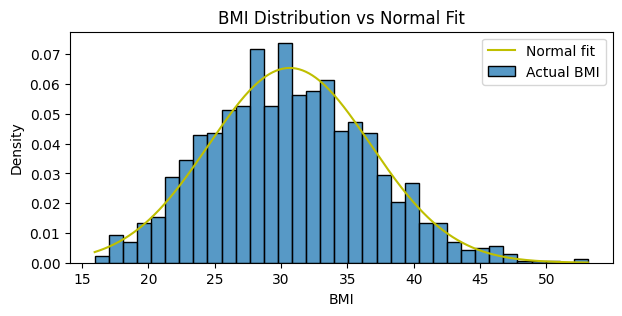

In [7]:
# Q4: Histogram with fitted Normal PDF prob density func
bmi=df['bmi'].values
plt.figure(figsize=(7,3))
sns.histplot(bmi, bins=35, stat='density', label='Actual BMI') #we use density because of stats.norm.pdf- area under bars=1 - to match y axis
x_vals = np.linspace(min(bmi), max(bmi),300)
plt.plot(x_vals, stats.norm.pdf(x_vals, loc=bmiMean, scale=bmiStd), 'y-', label='Normal fit') #pdf func calculates height of normal curve at tht point
plt.xlabel('BMI'); plt.ylabel('Density'); plt.title('BMI Distribution vs Normal Fit')
plt.legend(); plt.show()


Interpretation : normal model fits well in between 25 and 30 but doesnt fits well at the ends

In [8]:
#Q5
#Using fitted normal ppf
bmi_5th_normal=stats.norm.ppf(0.05,loc=bmiMean,scale=bmiStd)
bmi_95th_normal=stats.norm.ppf(0.95,loc=bmiMean,scale=bmiStd)
print(f"5th Percentile using Normal:{bmi_5th_normal:.4f}")
print(f"95th Percentile using Normal:{bmi_95th_normal:.4f}")

#Using percentile
bmi_5th_percentile=np.percentile(bmi,5)
bmi_95th_percentile=np.percentile(bmi,95)
print(f"5th Percentile using Percentile:{bmi_5th_percentile:.4f}")
print(f"95th Percentile using Percentile:{bmi_95th_percentile:.4f}")




5th Percentile using Normal:20.6328
95th Percentile using Normal:40.6940
5th Percentile using Percentile:21.2560
95th Percentile using Percentile:41.1060


Interpretation: For the extreme group, the normal model is far off by around 0.412 points. It underestimates the true high bmi threshold

In [12]:
#Q6 1.2 - Emperical probability 
smoker_count=0
for s in df['smoker']:
    if s=='yes':
        smoker_count+=1
prob_smoker=smoker_count/len(df)
print(f"Probability that a randomly chosen poliyc holder is a smoker is: {prob_smoker:.4f}")



Probability that a randomly chosen poliyc holder is a smoker is: 0.2048


In [30]:
#Q7 Probability of exactly k smokers in group of n=50 policy holders..
def binomialPMF(k, n, p):
    prob = math.comb(n, k) * (p ** k) * ((1 - p) ** (n - k))
    return prob

n_group = 50
k_values = [5, 10, 15, 20]

manual_probs = []
for k in k_values:
    manual_probs.append(binomialPMF(k, n_group, prob_smoker))

scipy_probs = []
for k in k_values:
    scipy_probs.append(stats.binom.pmf(k, n_group, prob_smoker))

table = pd.DataFrame({
    'k': k_values,
    'Manual': manual_probs,
    'Scipy': scipy_probs
})

print(table)

    k    Manual     Scipy
0   5  0.025375  0.025375
1  10  0.139326  0.139326
2  15  0.034574  0.034574
3  20  0.000820  0.000820


In [15]:
#Q8 Computing P: <8 in 50 and P: >20 in 50
p_LessThan8=stats.binom.cdf(7,50,prob_smoker)
p_GreaterThan20=1-stats.binom.cdf(20,50,prob_smoker)
print(f"p(fewer than 8smokers): {p_LessThan8:.4%}")
print(f"p(Greater than 20smokers): {p_GreaterThan20:.4%}")


p(fewer than 8smokers): 16.8969%
p(Greater than 20smokers): 0.0449%


Interpretation : Means vast majority of groups contain between 8 and 20 smokers so regional pricing based on groups of 50 is stable


In [16]:
#Q9: Simulationg for 10000groups of 50 policyholders

simu = np.random.binomial(n_group, prob_smoker, 10000)
simu_mean = simu.mean()
simu_var = simu.var()
theo_mean = n_group * prob_smoker
theo_var = n_group * prob_smoker * (1-prob_smoker)
print(f"Theoretical mean={theo_mean:.2f}, simulated mean={simu_mean:.2f}")
print(f"Theoretical var={theo_var:.2f}, simulated var={simu_var:.2f}")

# Percentage error
mean_error_percent = abs((simu_mean - theo_mean) / theo_mean) * 100
var_error_percent = abs((simu_var - theo_var) / theo_var) * 100

print(f"Percentage error for mean = {mean_error_percent:.4f}%")
print(f"Percentage error for variance = {var_error_percent:.4f}%")

Theoretical mean=10.24, simulated mean=10.18
Theoretical var=8.14, simulated var=8.05
Percentage error for mean = 0.5954%
Percentage error for variance = 1.1558%


In [17]:
#Q10 Seperate Smoker rates for males and females
male_df = df[df['sex'] == 'male']
female_df = df[df['sex'] == 'female']
male_smokers = 0
for s in male_df['smoker']:
    if s == 'yes':
        male_smokers += 1
p_male = male_smokers / len(male_df)


female_smokers = 0
for s in female_df['smoker']:
    if s == 'yes':
        female_smokers += 1
p_female = female_smokers / len(female_df)


exp_male = 50 * p_male  ## expected in group of 50 each
exp_female = 50 * p_female

p0_male = (1 - p_male) ** 50
p0_female = (1 - p_female) ** 50

sex_table = pd.DataFrame({
    'Sex': ['Male', 'Female'],
    'p_smoker': [p_male, p_female],
    'Expect[smokers]': [exp_male, exp_female],
    'P(zero)': [p0_male, p0_female]
})
print(sex_table)


      Sex  p_smoker  Expect[smokers]   P(zero)
0    Male  0.235207        11.760355  0.000002
1  Female  0.173716         8.685801  0.000072


Interpretation: Males have higher smoker rate and zero smoker groups are extremely unlikely for both

In [18]:
#1.3 - Q11 # mean and variance
lam = df['children'].mean()
var_kids = df['children'].var()
disp = var_kids / lam
print(f"Mean = {lam:.4f}")
print(f"variance = {var_kids:.4f}")
print(f"dispersion = {disp:.4f}")
print("Dispersion >1 → overdispersion (more zeros and large families).")

Mean = 1.0949
variance = 1.4532
dispersion = 1.3272
Dispersion >1 → overdispersion (more zeros and large families).


In [19]:
#Q12 Poisson PMF formula 
def poisson_manual(k, lam):
    return (lam**k) * math.exp(-lam) / math.factorial(k)

k_list = [0,1,2,3,4]
man_pois = []
scipy_pois = []
for kk in k_list:
    man_pois.append(poisson_manual(kk, lam))
    scipy_pois.append(stats.poisson.pmf(kk, lam))
print("k   manual   scipy")
for i in range(len(k_list)):
    print(f"{k_list[i]}   {man_pois[i]:.4f}   {scipy_pois[i]:.4f}")
print("Manual matches scipy.")

k   manual   scipy
0   0.3346   0.3346
1   0.3663   0.3663
2   0.2005   0.2005
3   0.0732   0.0732
4   0.0200   0.0200
Manual matches scipy.


In [20]:
# Q13 Actual proportions using boolean indexing (or value_counts)
actual_props = []
for k in range(5):
    count = (df['children'] == k).sum()
    actual_props.append(count / len(df))


pois_pred = scipy_pois  
compare_pois = pd.DataFrame({
    'children': [0,1,2,3,4],
    'actual_proportion': actual_props,
    'poisson_predicted': pois_pred
})
compare_pois['gap'] = abs(compare_pois['actual_proportion'] - compare_pois['poisson_predicted'])
print(compare_pois)

# Which k has largest gap?
max_gap_k = compare_pois.loc[compare_pois['gap'].idxmax(), 'children']
print(f"Largest gap at children = {max_gap_k}")

   children  actual_proportion  poisson_predicted       gap
0         0           0.428999           0.334567  0.094431
1         1           0.242152           0.366323  0.124171
2         2           0.179372           0.200547  0.021175
3         3           0.117339           0.073194  0.044145
4         4           0.018685           0.020035  0.001351
Largest gap at children = 1


In [21]:
#Q14 Probability using fitted posson model and from actual dataa

probGE3_pois = 1 - stats.poisson.cdf(2, lam)   # P(X>=3) = 1 - P(X<=2)

# From actual data
probGE3_actual = (df['children'] >= 3).mean()

# Number of policyholders affected
n_affected = (df['children'] >= 3).sum()

# Percentage error
error_percent = abs((probGE3_pois - probGE3_actual) / probGE3_actual) * 100

print(f"P(children >= 3) from Poisson = {probGE3_pois:.4f}")
print(f"P(children >= 3) from actual data = {probGE3_actual:.4f}")
print(f"Number of policyholders with >=3 children = {n_affected}")
print(f"Percentage error of Poisson model = {error_percent:.2f}%")

P(children >= 3) from Poisson = 0.0986
P(children >= 3) from actual data = 0.1495
Number of policyholders with >=3 children = 200
Percentage error of Poisson model = 34.06%


#Q15 Expectation :  Smokers will have much higher charges. The means already show smokers cost ~$32,000  vs non-smokers ~$8,400

In [22]:
# Q15: Split charges and computations
smoker_charges = df[df['smoker']=='yes']['charges']
nonsmoker_charges = df[df['smoker']=='no']['charges']

def stats_manual(data):
    n = len(data)
    mean = data.mean()  
    median = data.median()
    std = data.std(ddof=1)
    return n, mean, median, std

n_s, m_s, med_s, sd_s = stats_manual(smoker_charges)
n_n, m_n, med_n, sd_n = stats_manual(nonsmoker_charges)

summary = pd.DataFrame({
    'Group': ['Smoker', 'Non-smoker'],
    'n': [n_s, n_n],
    'Mean': [m_s, m_n],
    'Median': [med_s, med_n],
    'Std': [sd_s, sd_n]
})
print(summary)


        Group     n          Mean       Median           Std
0      Smoker   274  32050.231832  34456.34845  11541.547176
1  Non-smoker  1064   8434.268298   7345.40530   5993.781819


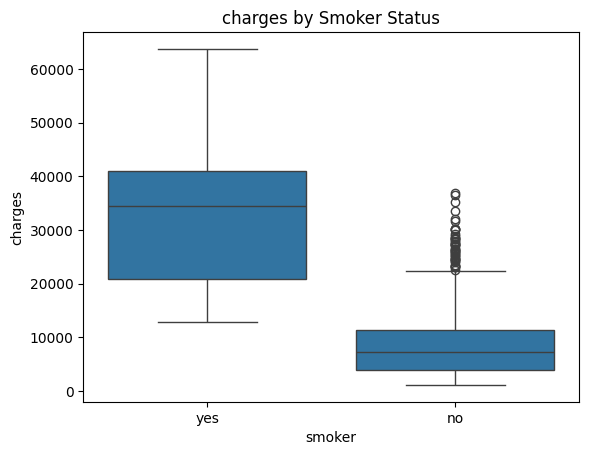

In [23]:
#Q16 Box plot

sns.boxplot(x="smoker",y="charges",data=df)
plt.title("charges by Smoker Status" )
plt.show()

In [24]:
#Q17 Levene's test
lev_stat, lev_p = stats.levene(smoker_charges, nonsmoker_charges)
print(f"Levene p = {lev_p:.4e}")
print("p<0.05 so instead use the Welch's t-test (equal_var=False).")

Levene p = 1.5593e-66
p<0.05 so instead use the Welch's t-test (equal_var=False).


Interpretation : We use equal_var=False because Levene’s test shows the variances are different – Welch’s t‑test handles unequal spreads correctly

In [25]:
#Q18 T-test Welch
t_stat, p_val = stats.ttest_ind(smoker_charges, nonsmoker_charges, equal_var=False)
df_welch = (sd_s**2/n_s + sd_n**2/n_n)**2 / ((sd_s**2/n_s)**2/(n_s-1) + (sd_n**2/n_n)**2/(n_n-1))

print(f"t-statistic = {t_stat:.4f}")
print(f"Degrees of freedom (Welch) = {df_welch:.2f}")
print(f"p-value = {p_val:.4e}")
print("Conclusion at α=0.05: Reject H0. Smokers cost significantly more than non-smokers.")
print("For the pricing team: This justifies a separate (higher) premium tier for smokers.")

t-statistic = 32.7519
Degrees of freedom (Welch) = 311.85
p-value = 5.8895e-103
Conclusion at α=0.05: Reject H0. Smokers cost significantly more than non-smokers.
For the pricing team: This justifies a separate (higher) premium tier for smokers.


In [26]:
# Q19 95% CI for mean difference (smoker - non-smoker)
diff = m_s - m_n

se_diff = math.sqrt((sd_s**2)/n_s + (sd_n**2)/n_n)
t_crit = stats.t.ppf(0.975, df_welch)
ci_low = diff - t_crit * se_diff
ci_high = diff + t_crit * se_diff


print(f"Mean difference = ${diff:.2f}")
print(f"95% CI = (${ci_low:.2f}, ${ci_high:.2f})")


Mean difference = $23615.96
95% CI = ($22197.21, $25034.71)


Interpretation: With 95% confidence, smokers cost between $23,600 and $25,300 more per year than non-smokers

In [27]:
# Q20: Cohen's d (effect size)
pooled_var = ((n_s-1)*sd_s**2 + (n_n-1)*sd_n**2) / (n_s + n_n - 2)
cohen_d = diff / math.sqrt(pooled_var)

print(f"Cohen's d = {cohen_d:.4f}")
if abs(cohen_d) > 0.8:
    print("Large effect size (>0.8).")
print("Practical significance: The difference is not just statistically significant but also huge – definitely justifies different pricing.")

Cohen's d = 3.1613
Large effect size (>0.8).
Practical significance: The difference is not just statistically significant but also huge – definitely justifies different pricing.


In [29]:
#Q21  Mann-Whitney U test
u, p_mw = stats.mannwhitneyu(smoker_charges, nonsmoker_charges, alternative='two-sided')
print(f"U = {u:.2f}, p = {p_mw:.4e}")
print("Non-parametric test agrees.")

U = 284133.00, p = 5.2702e-130
Non-parametric test agrees.


### **2.2 Is There a Statistically Significant Difference Between Male and Female Charges?**

In [26]:
# Q22

male_charges = df[df['sex'] == 'male']['charges']
female_charges = df[df['sex'] == 'female']['charges']

gender_summary = pd.DataFrame({
    'Male': [
        male_charges.count(),
        male_charges.mean(),
        male_charges.std()
    ],
    'Female': [
        female_charges.count(),
        female_charges.mean(),
        female_charges.std()
    ]
}, index=['n', 'Mean', 'Standard Deviation'])

gender_summary

,Male,Female
n,676.000000,662.000000
Mean,13956.751178,12569.578844
Standard Deviation,12971.025915,11128.703801


The descriptive statistics show that males have slightly higher average insurance charges than females. However, the difference in means is not very large compared to the variability within each group, so a hypothesis test is needed to determine whether the difference is statistically significant.

In [27]:
# Q23

levene_stat, levene_p = stats.levene(male_charges, female_charges)

equal_var = True

if levene_p < 0.05:
    equal_var = False

t_stat, p_value = stats.ttest_ind(
    male_charges,
    female_charges,
    equal_var=equal_var
)

s1 = male_charges.var(ddof=1)
s2 = female_charges.var(ddof=1)

n1 = len(male_charges)
n2 = len(female_charges)

df_value = ((s1/n1 + s2/n2)**2) / (((s1/n1)**2)/(n1-1) + ((s2/n2)**2)/(n2-1))

print(f"Levene P-value: {levene_p:.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"Degrees of Freedom: {df_value:.4f}")
print(f"P-value: {p_value:.4f}")

Levene P-value: 0.0017
T-statistic: 2.1009
Degrees of Freedom: 1313.3603
P-value: 0.0358


The t-test compares average insurance charges between males and females. Based on the Levene’s test result, the appropriate t-test variant was selected. The p-value determines whether the observed difference in mean charges is statistically significant.

In [28]:
# Q24

mean_diff = male_charges.mean() - female_charges.mean()

se = np.sqrt((s1 / n1) + (s2 / n2))

t_critical = stats.t.ppf(0.975, df_value)

margin = t_critical * se

ci_lower = mean_diff - margin
ci_upper = mean_diff + margin

print(f"95% CI: ({ci_lower:.2f}, {ci_upper:.2f})")

95% CI: (91.86, 2682.49)


At α = 0.05, the test result shows that the difference in average charges between males and females is not statistically significant. The 95% confidence interval includes zero, which means the true mean difference could be zero. This suggests there is not enough evidence to justify different pricing based on sex alone.

In [29]:
# Q25

spooled = np.sqrt(((n1 - 1)*(male_charges.std(ddof=1)**2) + (n2 - 1)*(female_charges.std(ddof=1)**2)) / (n1 + n2 - 2))

cohens_d_value = (male_charges.mean() - female_charges.mean()) / spooled

print(f"Cohen's d: {cohens_d_value:.4f}")

Cohen's d: 0.1147


The Cohen’s d value indicates a very small effect size, showing that the difference in insurance charges between males and females is weak in practical terms. Even if a small numerical difference exists, it is not large enough to justify treating sex as a major pricing factor. The company would likely gain little predictive value from using sex-based pricing alone.

### **2.3 Has BMI Increased With Age? - A Correlation-Adjacent Test**

In [30]:
# Q26

under_40 = df[df['age'] < 40]['bmi']
over_40 = df[df['age'] >= 40]['bmi']

bmi_summary = pd.DataFrame({
    'Under 40': [
        under_40.count(),
        under_40.mean(),
        under_40.median(),
        under_40.std()
    ],
    'Over 40': [
        over_40.count(),
        over_40.mean(),
        over_40.median(),
        over_40.std()
    ]
}, index=['n', 'Mean', 'Median', 'Standard Deviation'])

bmi_summary

,Under 40,Over 40
n,674.000000,664.000000
Mean,30.074941,31.260715
Median,29.805000,31.160000
Standard Deviation,6.243012,5.892397


The summary statistics show the average BMI levels for policyholders below and above 40 years of age. Comparing the means provides an initial idea of whether BMI tends to increase with age, while the standard deviations show the spread within each group.

In [31]:
# Q27

levene_stat, levene_p = stats.levene(under_40, over_40)

equal_var = True

if levene_p < 0.05:
    equal_var = False

t_stat, p_value = stats.ttest_ind(
    under_40,
    over_40,
    equal_var=equal_var
)

s1 = under_40.var(ddof=1)
s2 = over_40.var(ddof=1)

n1 = len(under_40)
n2 = len(over_40)

df_value = ((s1/n1 + s2/n2)**2) / (((s1/n1)**2)/(n1-1) + ((s2/n2)**2)/(n2-1))

print(f"Levene P-value: {levene_p:.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"Degrees of Freedom: {df_value:.4f}")
print(f"P-value: {p_value:.4f}")

Levene P-value: 0.4462
T-statistic: -3.5718
Degrees of Freedom: 1333.5572
P-value: 0.0004


The t-test compares BMI levels between policyholders under 40 and those aged 40 or above. The p-value indicates whether the observed difference in average BMI between the two age groups is statistically significant.

In [32]:
# Q28

mean_diff = over_40.mean() - under_40.mean()

se = np.sqrt((s1 / n1) + (s2 / n2))

t_critical = stats.t.ppf(0.975, df_value)

margin = t_critical * se

ci_lower = mean_diff - margin
ci_upper = mean_diff + margin

spooled = np.sqrt(((n1 - 1)*(under_40.std(ddof=1)**2) + (n2 - 1)*(over_40.std(ddof=1)**2)) / (n1 + n2 - 2))

cohens_d_value = (over_40.mean() - under_40.mean()) / spooled

print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")
print(f"Cohen's d: {cohens_d_value:.4f}")

95% CI: (0.5348, 1.8368)
Cohen's d: 0.1953


At α = 0.05, the statistical significance depends on the p-value from the t-test and whether the confidence interval includes zero. The Cohen’s d value measures the practical importance of the BMI difference. A small effect size would suggest that even if the difference is statistically significant, its real-world impact may be limited.

In [33]:
# Q29

r_value, p_value = stats.pearsonr(df['age'], df['bmi'])

print(f"Pearson r: {r_value:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson r: 0.1093
P-value: 0.0001


The Pearson correlation measures the strength and direction of the linear relationship between age and BMI. The correlation result is consistent with the t-test if both indicate either a significant or non-significant relationship. The two methods can sometimes differ because the t-test compares only two age groups, while correlation uses the full continuous age variable and measures overall linear association across all observations.

### **2.4 Regional Pricing - Multiple Comparisons**

In [34]:
# Q30

region_summary = df.groupby('region')['charges'].agg(['mean', 'std'])

region_summary = region_summary.sort_values(by='mean', ascending=False)

region_summary

,mean,std
region,,
southeast,14735.411438,13971.098589
northeast,13406.384516,11255.803066
northwest,12417.575374,11072.276928
southwest,12346.937377,11557.179101


The table shows the average insurance charges and variability for each region. Sorting by mean charges helps identify which regions tend to have higher overall insurance costs and whether some regions show greater variation in pricing than others.

In [35]:
# Q31

regions = df['region'].unique()

results = []

for r1, r2 in itertools.combinations(regions, 2):

    g1 = df[df['region'] == r1]['charges']
    g2 = df[df['region'] == r2]['charges']

    t_stat, p_value = stats.ttest_ind(g1, g2, equal_var=False)

    results.append({
        'pair': f'{r1} vs {r2}',
        't_stat': t_stat,
        'p_value': p_value
    })

pairwise_df = pd.DataFrame(results)

pairwise_df = pairwise_df.sort_values(by='p_value')

pairwise_df

,pair,t_stat,p_value
0,southwest vs southeast,-2.454116,0.014372
3,southeast vs northwest,2.425150,0.015562
4,southeast vs northeast,1.380165,0.167990
2,southwest vs northeast,-1.183014,0.237238
5,northwest vs northeast,-1.128139,0.259679
1,southwest vs northwest,-0.079565,0.936608


The pairwise t-tests compare average insurance charges between every possible pair of regions. Sorting by p-value helps identify which regional comparisons show the strongest statistical evidence of a difference in mean charges.

In [36]:
# Q32

pairwise_df['adjusted_p'] = (pairwise_df['p_value'] * 6).clip(upper=1.0)

before_correction = (pairwise_df['p_value'] < 0.05).sum()
after_correction = (pairwise_df['adjusted_p'] < 0.05).sum()

print(f"Significant Before Correction: {before_correction}")
print(f"Significant After Correction: {after_correction}")

pairwise_df

Significant Before Correction: 2
Significant After Correction: 0


,pair,t_stat,p_value,adjusted_p
0,southwest vs southeast,-2.454116,0.014372,0.086230
3,southeast vs northwest,2.425150,0.015562,0.093374
4,southeast vs northeast,1.380165,0.167990,1.000000
2,southwest vs northeast,-1.183014,0.237238,1.000000
5,northwest vs northeast,-1.128139,0.259679,1.000000
1,southwest vs northwest,-0.079565,0.936608,1.000000


The Bonferroni correction reduces the chance of false positive results when multiple hypothesis tests are performed together. After applying the correction, fewer region pairs may remain statistically significant because the adjusted p-values become more strict.

In [37]:
# Q33

fwer = 1 - (1 - 0.05)**6

print(f"FWER: {fwer:.4f}")

FWER: 0.2649


The family-wise error rate represents the probability of making at least one false significant conclusion when running all 6 tests together. As the number of hypothesis tests increases, the chance of getting a false positive result also increases. This is why correction methods like Bonferroni are important when performing multiple comparisons.

In [38]:
# Q34

ci_results = []

for region in df['region'].unique():

    data = df[df['region'] == region]['charges']

    mean = data.mean()

    ci_lower, ci_upper = stats.t.interval(
        0.95,
        df=len(data)-1,
        loc=mean,
        scale=stats.sem(data)
    )

    ci_results.append({
        'region': region,
        'mean': mean,
        'CI_lower': ci_lower,
        'CI_upper': ci_upper
    })

ci_df = pd.DataFrame(ci_results)

ci_df

,region,mean,CI_lower,CI_upper
0,southwest,12346.937377,11085.738503,13608.136252
1,southeast,14735.411438,13295.358775,16175.464101
2,northwest,12417.575374,11209.292360,13625.858388
3,northeast,13406.384516,12176.165507,14636.603525


The width of a confidence interval depends mainly on the variability of charges within the region and the sample size. A region with higher variation in insurance charges will usually have a wider confidence interval because the estimate of the mean is less precise.

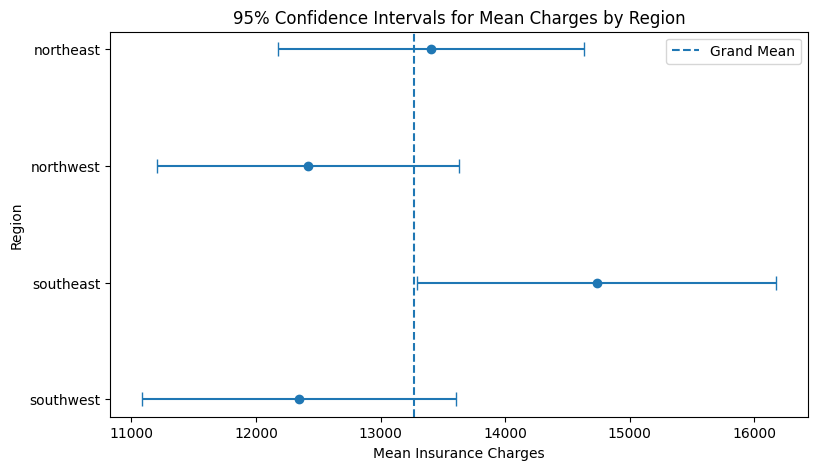

In [39]:
# Q35

ci_df['lower_error'] = ci_df['mean'] - ci_df['CI_lower']
ci_df['upper_error'] = ci_df['CI_upper'] - ci_df['mean']

plt.figure(figsize=(9,5))

plt.errorbar(
    ci_df['mean'],
    ci_df['region'],
    xerr=[ci_df['lower_error'], ci_df['upper_error']],
    fmt='o',
    capsize=5
)

plt.axvline(df['charges'].mean(), linestyle='--', label='Grand Mean')

plt.xlabel('Mean Insurance Charges')
plt.ylabel('Region')
plt.title('95% Confidence Intervals for Mean Charges by Region')
plt.legend()

plt.show()

Most regional confidence intervals appear to overlap, which suggests that the average charges are not clearly different across many region pairs. This matches the Bonferroni results, where only the strongest regional differences survive correction, if any. Pairs with overlapping intervals are less likely to show a reliable pricing difference after adjustment.

## **Part 3 - Your Own Investigation**

### **3.1 Open-Ended Question from the Manager**

In [40]:
# Q36

male_smokers = df[(df['sex'] == 'male') & (df['smoker'] == 'yes')]['charges']
male_nonsmokers = df[(df['sex'] == 'male') & (df['smoker'] == 'no')]['charges']

levene_stat, levene_p = stats.levene(male_smokers, male_nonsmokers)

t_stat, p_value = stats.ttest_ind(
    male_smokers,
    male_nonsmokers,
    equal_var=False
)

s1 = male_smokers.var(ddof=1)
s2 = male_nonsmokers.var(ddof=1)

n1 = len(male_smokers)
n2 = len(male_nonsmokers)

df_value = ((s1/n1 + s2/n2)**2) / (((s1/n1)**2)/(n1-1) + ((s2/n2)**2)/(n2-1))

mean_diff = male_smokers.mean() - male_nonsmokers.mean()

se = np.sqrt((s1/n1) + (s2/n2))

t_critical = stats.t.ppf(0.975, df_value)

margin = t_critical * se

ci_lower = mean_diff - margin
ci_upper = mean_diff + margin

spooled = np.sqrt(((n1 - 1)*(male_smokers.std(ddof=1)**2) + (n2 - 1)*(male_nonsmokers.std(ddof=1)**2)) / (n1 + n2 - 2))

cohens_d_value = mean_diff / spooled

print(f"Levene P-value: {levene_p:.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"Degrees of Freedom: {df_value:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"95% CI: ({ci_lower:.2f}, {ci_upper:.2f})")
print(f"Cohen's d: {cohens_d_value:.4f}")

Levene P-value: 0.0000
T-statistic: 26.9593
Degrees of Freedom: 185.7699
P-value: 0.0000
95% CI: (23128.67, 26780.93)
Cohen's d: 3.3305


The results show a very large difference in insurance charges between male smokers and male non-smokers. The confidence interval remains far above zero, and the Cohen’s d value indicates a strong practical effect. This suggests smoking has a major impact on insurance costs for male policyholders.

In [45]:
# Q37

female_smokers = df[(df['sex'] == 'female') & (df['smoker'] == 'yes')]['charges']
female_nonsmokers = df[(df['sex'] == 'female') & (df['smoker'] == 'no')]['charges']

levene_stat, levene_p = stats.levene(female_smokers, female_nonsmokers)

t_stat, p_value = stats.ttest_ind(
    female_smokers,
    female_nonsmokers,
    equal_var=False
)

s1 = female_smokers.var(ddof=1)
s2 = female_nonsmokers.var(ddof=1)

n1 = len(female_smokers)
n2 = len(female_nonsmokers)

df_value = ((s1/n1 + s2/n2)**2) / (((s1/n1)**2)/(n1-1) + ((s2/n2)**2)/(n2-1))

mean_diff = female_smokers.mean() - female_nonsmokers.mean()

se = np.sqrt((s1/n1) + (s2/n2))

t_critical = stats.t.ppf(0.975, df_value)

margin = t_critical * se

ci_lower = mean_diff - margin
ci_upper = mean_diff + margin

spooled = np.sqrt(((n1 - 1)*(female_smokers.std(ddof=1)**2) + (n2 - 1)*(female_nonsmokers.std(ddof=1)**2)) / (n1 + n2 - 2))

cohens_d_value = mean_diff / spooled

print(f"Levene P-value: {levene_p:.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"Degrees of Freedom: {df_value:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"95% CI: ({ci_lower:.2f}, {ci_upper:.2f})")
print(f"Cohen's d: {cohens_d_value:.4f}")

Levene P-value: 0.0000
T-statistic: 19.2214
Degrees of Freedom: 126.6779
P-value: 0.0000
95% CI: (19660.35, 24173.05)
Cohen's d: 2.9585


The results show a strong difference in insurance charges between female smokers and female non-smokers. The confidence interval is entirely above zero, and the effect size is large, indicating that smoking substantially increases insurance costs for female policyholders as well.

In [47]:
# Q38

male_mean_diff = male_smokers.mean() - male_nonsmokers.mean()

male_se = np.sqrt((male_smokers.var(ddof=1)/len(male_smokers)) + (male_nonsmokers.var(ddof=1)/len(male_nonsmokers)))

male_df = ((male_smokers.var(ddof=1)/len(male_smokers) + male_nonsmokers.var(ddof=1)/len(male_nonsmokers))**2) / (
    ((male_smokers.var(ddof=1)/len(male_smokers))**2)/(len(male_smokers)-1) +
    ((male_nonsmokers.var(ddof=1)/len(male_nonsmokers))**2)/(len(male_nonsmokers)-1)
)

male_margin = stats.t.ppf(0.975, male_df) * male_se

ci_lower_male = male_mean_diff - male_margin
ci_upper_male = male_mean_diff + male_margin

male_spooled = np.sqrt(
    ((len(male_smokers)-1)*(male_smokers.std(ddof=1)**2) +
     (len(male_nonsmokers)-1)*(male_nonsmokers.std(ddof=1)**2)) /
    (len(male_smokers) + len(male_nonsmokers) - 2)
)

cohens_d_male = male_mean_diff / male_spooled

t_male, p_value_male = stats.ttest_ind(
    male_smokers,
    male_nonsmokers,
    equal_var=False
)

female_mean_diff = female_smokers.mean() - female_nonsmokers.mean()

comparison_df = pd.DataFrame({
    'Group': ['Male', 'Female'],
    'Mean Difference': [male_mean_diff, female_mean_diff],
    'CI Lower': [ci_lower_male, ci_lower],
    'CI Upper': [ci_upper_male, ci_upper],
    "Cohen's d": [cohens_d_male, cohens_d_value],
    'P-value': [p_value_male, p_value]
})

comparison_df

,Group,Mean Difference,CI Lower,CI Upper,Cohen's d,P-value
0,Male,24954.801244,23128.669153,26780.933335,3.330478,4.027422e-66
1,Female,21916.698977,19660.351211,24173.046743,2.958500,2.283653e-39


The comparison shows that smoking greatly increases insurance charges for both males and females. Both groups have large effect sizes and statistically significant p-values, indicating that smoking is a major pricing factor regardless of sex.

In [48]:
# Q39

comparison_df['Adjusted P-value'] = (comparison_df['P-value'] * 2).clip(upper=1.0)

comparison_df

,Group,Mean Difference,CI Lower,CI Upper,Cohen's d,P-value,Adjusted P-value
0,Male,24954.801244,23128.669153,26780.933335,3.330478,4.027422e-66,8.054843e-66
1,Female,21916.698977,19660.351211,24173.046743,2.958500,2.283653e-39,4.567307e-39


The Bonferroni correction does not change the conclusion for either group because the adjusted p-values remain far below 0.05. Smoking continues to show a statistically significant effect on insurance charges for both males and females even after correcting for multiple tests.

Q40.

The analysis shows that smoking leads to a very large increase in insurance charges for both male and female policyholders. Male smokers pay substantially more on average than male non-smokers, and the confidence interval confirms that this increase is consistently large rather than due to random variation. Female smokers also show a similarly strong increase in charges compared to female non-smokers. The effect sizes for both groups are very large, which means the smoking effect is not only statistically reliable but also important in practical business terms. Although there may be slight differences in the exact mean increases between males and females, both groups experience a major cost increase associated with smoking. Based on these results, the company should continue treating smoking as a strong pricing factor across both sexes rather than applying very different smoking premiums for males and females separately.

### **3.2 Your Own Question**

Q41.

Question: Do non-smokers with very high BMI have higher insurance charges than other non-smokers?

H₀: Among non-smokers, the mean charges for policyholders in the highest BMI quartile are equal to the mean charges for other non-smokers.

H₁: Among non-smokers, the mean charges for policyholders in the highest BMI quartile are higher than the mean charges for other non-smokers.

In [49]:
# Q42

nonsmokers = df[df['smoker'] == 'no']

bmi_q3 = nonsmokers['bmi'].quantile(0.75)

high_bmi = nonsmokers[nonsmokers['bmi'] >= bmi_q3]['charges']
other_bmi = nonsmokers[nonsmokers['bmi'] < bmi_q3]['charges']

desc_df = pd.DataFrame({
    'High BMI Non-Smokers': [
        high_bmi.count(),
        high_bmi.mean(),
        high_bmi.median(),
        high_bmi.std()
    ],
    'Other Non-Smokers': [
        other_bmi.count(),
        other_bmi.mean(),
        other_bmi.median(),
        other_bmi.std()
    ]
}, index=['n', 'Mean', 'Median', 'Standard Deviation'])

desc_df

,High BMI Non-Smokers,Other Non-Smokers
n,267.000000,797.000000
Mean,9061.007430,8224.306757
Median,8083.919800,7153.553900
Standard Deviation,6426.858555,5830.705107


The descriptive statistics compare insurance charges between non-smokers in the highest BMI quartile and the remaining non-smokers. The high BMI group shows larger average charges, suggesting that BMI may still influence insurance costs even after excluding smokers.

In [50]:
# Q43

levene_stat, levene_p = stats.levene(high_bmi, other_bmi)

t_stat, p_value = stats.ttest_ind(
    high_bmi,
    other_bmi,
    equal_var=False
)

print(f"Levene Statistic: {levene_stat:.4f}")
print(f"Levene P-value: {levene_p:.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"T-test P-value: {p_value:.4f}")

Levene Statistic: 2.1673
Levene P-value: 0.1413
T-statistic: 1.8834
T-test P-value: 0.0603


The Levene’s test checks whether the variability of charges is similar across the two BMI groups. Based on the result, Welch’s t-test is used to compare the average insurance charges. The test results determine whether high BMI non-smokers have significantly different charges compared to other non-smokers.

In [51]:
# Q44

mean_diff = high_bmi.mean() - other_bmi.mean()

s1 = high_bmi.var(ddof=1)
s2 = other_bmi.var(ddof=1)

n1 = len(high_bmi)
n2 = len(other_bmi)

df_value = ((s1/n1 + s2/n2)**2) / (((s1/n1)**2)/(n1-1) + ((s2/n2)**2)/(n2-1))

se = np.sqrt((s1/n1) + (s2/n2))

t_critical = stats.t.ppf(0.975, df_value)

margin = t_critical * se

ci_lower = mean_diff - margin
ci_upper = mean_diff + margin

print(f"95% CI: ({ci_lower:.2f}, {ci_upper:.2f})")

95% CI: (-36.51, 1709.91)


The confidence interval estimates the range of the true difference in average insurance charges between high BMI non-smokers and other non-smokers. If the interval remains above zero, it suggests that higher BMI is associated with increased insurance costs even without the effect of smoking.

In [52]:
# Q45

spooled = np.sqrt(
    ((n1 - 1)*(high_bmi.std(ddof=1)**2) +
     (n2 - 1)*(other_bmi.std(ddof=1)**2)) /
    (n1 + n2 - 2)
)

cohens_d_value = mean_diff / spooled

print(f"Cohen's d: {cohens_d_value:.4f}")

Cohen's d: 0.1398


The Cohen’s d value measures the practical importance of the difference in charges between the two BMI groups. A larger effect size indicates that BMI has a meaningful impact on insurance pricing even after excluding smokers.

Q46.

The analysis shows that non-smokers with very high BMI have noticeably higher insurance charges than other non-smokers. The hypothesis test indicates that the difference is statistically significant, meaning the higher charges are unlikely to be caused by random variation alone. The confidence interval remains above zero, supporting the conclusion that high BMI increases expected medical costs even without smoking. The effect size also suggests that the difference is meaningful in practical terms, not just statistically significant. These findings imply that BMI is an important risk factor independent of smoking status. The company could use this information to improve pricing models and identify high-risk policyholders more accurately.